# ASSIGNMENT NLP – 4  
## Chatbot using Hugging Face Transformers

### Objective
Build a console-based chatbot using a pre-trained transformer model from Hugging Face that can interact with users and generate meaningful responses.

### Model Used
- microsoft/Phi-3-mini-4k-instruct

### Tools and Technologies
- Python
- Hugging Face Transformers
- PyTorch
- Jupyter Notebook / Google Colab

In [1]:
!pip install -q transformers datasets evaluate accelerate kaggle scikit-learn seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.4 MB/s eta 0:00:00


In [2]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"aparitosh","key":"2069c59fc80d494cea87701adb9a2e8b"}'}

In [3]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [4]:
!kaggle datasets download -d lakshmi25npathi/imdb-dataset-of-50k-movie-reviews
!unzip -q imdb-dataset-of-50k-movie-reviews.zip -d imdb_data

Dataset URL: https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews
License(s): other
100% 25.7M/25.7M [00:00<00:00, 180MB/s]



In [5]:
import os
import re
import gc
import random
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

import torch
from torch.utils.data import Dataset

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    EarlyStoppingCallback
)

In [6]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [8]:
df = pd.read_csv("/content/imdb_data/IMDB Dataset.csv")
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [9]:
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nMissing values:\n", df.isnull().sum())
print("\nClass distribution:\n", df["sentiment"].value_counts())

Shape: (50000, 2)

Columns: ['review', 'sentiment']

Missing values:
 review       0
sentiment    0
dtype: int64

Class distribution:
 sentiment
positive    25000
negative    25000
Name: count, dtype: int64


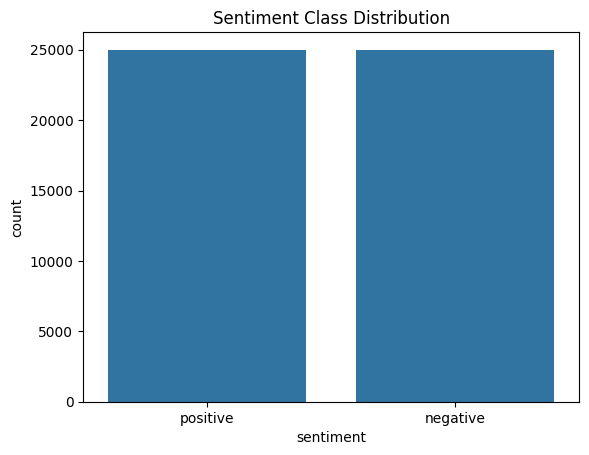

In [10]:
sns.countplot(x="sentiment", data=df)
plt.title("Sentiment Class Distribution")
plt.show()

In [11]:
def clean_text(text):
    text = str(text)
    text = re.sub(r"<.*?>", " ", text)     # remove HTML tags
    text = re.sub(r"\s+", " ", text)       # remove extra spaces
    text = text.strip()
    return text

In [12]:
df = df.dropna(subset=["review", "sentiment"]).copy()
df["review"] = df["review"].apply(clean_text)
df["label"] = df["sentiment"].map({"negative": 0, "positive": 1})
df = df[["review", "label"]].rename(columns={"review": "text"})
df.head()

,text,label
0,One of the other reviewers has mentioned that ...,1
1,A wonderful little production. The filming tec...,1
2,I thought this was a wonderful way to spend ti...,1
3,Basically there's a family where a little boy ...,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",1


In [13]:
df["char_len"] = df["text"].apply(len)
df["word_len"] = df["text"].apply(lambda x: len(x.split()))

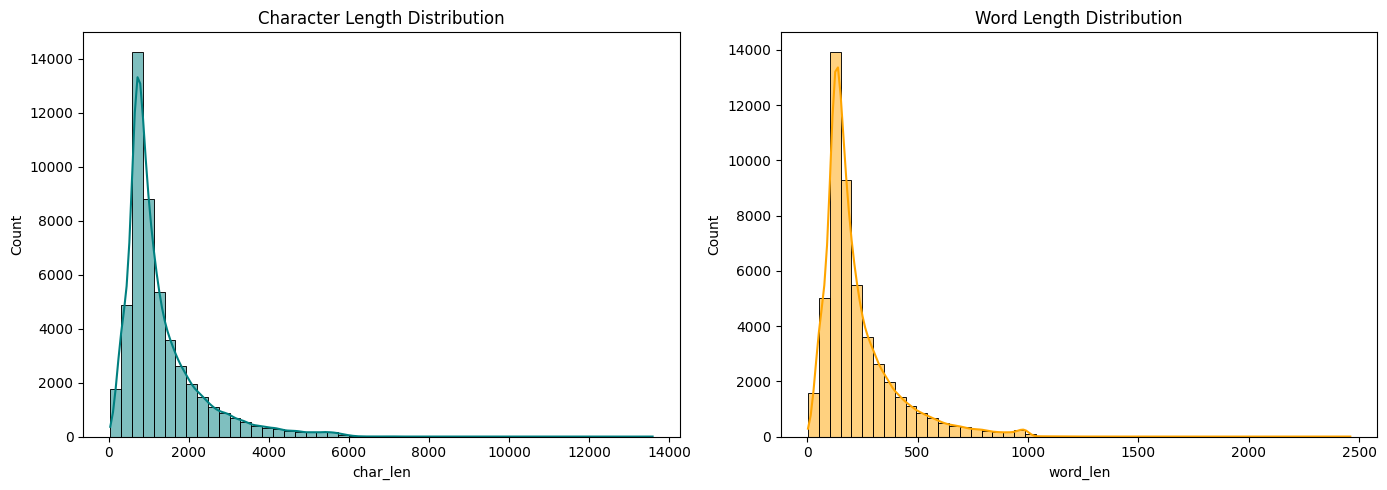

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df["char_len"], bins=50, kde=True, ax=axes[0], color="teal")
axes[0].set_title("Character Length Distribution")

sns.histplot(df["word_len"], bins=50, kde=True, ax=axes[1], color="orange")
axes[1].set_title("Word Length Distribution")

plt.tight_layout()
plt.show()

In [15]:
print("Sample Positive Review:\n")
print(df[df["label"] == 1]["text"].iloc[0])

print("\n" + "="*120 + "\n")

print("Sample Negative Review:\n")
print(df[df["label"] == 0]["text"].iloc[0])

Sample Positive Review:

One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me. The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word. It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away. I would say the main appeal of the show is due to the fact that i

In [16]:
train_df, temp_df = train_test_split(
    df[["text", "label"]],
    test_size=0.2,
    random_state=42,
    stratify=df["label"]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    random_state=42,
    stratify=temp_df["label"]
)

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)

Train shape: (40000, 2)
Validation shape: (5000, 2)
Test shape: (5000, 2)


In [17]:
model_checkpoint = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [18]:
sample_token_lengths = train_df["text"].sample(2000, random_state=42).apply(
    lambda x: len(tokenizer.encode(x, truncation=False))
)

print(sample_token_lengths.describe())

Token indices sequence length is longer than the specified maximum sequence length for this model (693 > 512). Running this sequence through the model will result in indexing errors


count    2000.000000
mean      298.245000
std       223.685745
min        11.000000
25%       162.000000
50%       221.000000
75%       364.500000
max      3047.000000
Name: text, dtype: float64


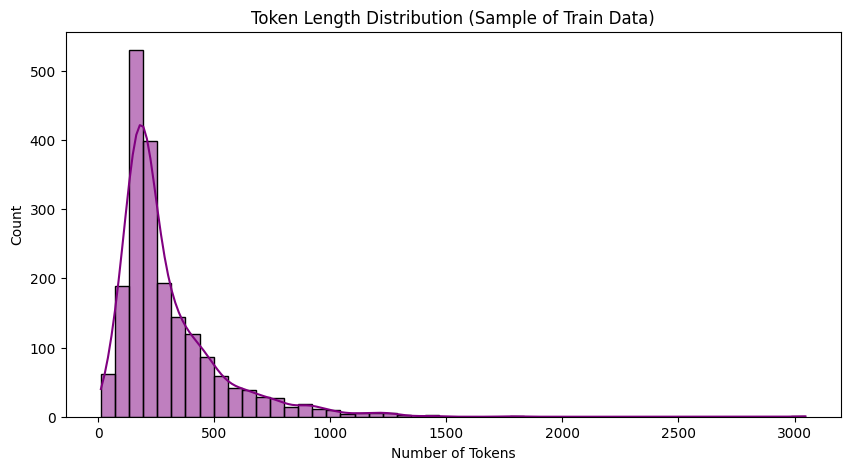

In [19]:
plt.figure(figsize=(10, 5))
sns.histplot(sample_token_lengths, bins=50, kde=True, color="purple")
plt.title("Token Length Distribution (Sample of Train Data)")
plt.xlabel("Number of Tokens")
plt.show()

In [20]:
max_length = 256
print("Using max_length =", max_length)

Using max_length = 256


In [21]:
class IMDBDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length):
        self.texts = texts.tolist()
        self.labels = labels.tolist()
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            truncation=True,
            max_length=self.max_length,
            padding=False,
            return_tensors="pt"
        )

        item = {key: value.squeeze(0) for key, value in encoding.items()}
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

In [22]:
train_dataset = IMDBDataset(train_df["text"], train_df["label"], tokenizer, max_length)
val_dataset = IMDBDataset(val_df["text"], val_df["label"], tokenizer, max_length)
test_dataset = IMDBDataset(test_df["text"], test_df["label"], tokenizer, max_length)

In [23]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

In [24]:
id2label = {0: "NEGATIVE", 1: "POSITIVE"}
label2id = {"NEGATIVE": 0, "POSITIVE": 1}

In [25]:
def get_model():
    model = AutoModelForSequenceClassification.from_pretrained(
        model_checkpoint,
        num_labels=2,
        id2label=id2label,
        label2id=label2id
    )
    return model

In [26]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average="binary"
    )
    acc = accuracy_score(labels, preds)

    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

In [33]:
def train_and_evaluate(model, experiment_name, output_dir):
    training_args = TrainingArguments(
        output_dir=output_dir,
        learning_rate=2e-5,
        per_device_train_batch_size=8,
        per_device_eval_batch_size=8,
        num_train_epochs=2,
        weight_decay=0.01,
        eval_strategy="epoch",
        save_strategy="epoch",
        logging_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="f1",
        greater_is_better=True,
        report_to="none",
        fp16=torch.cuda.is_available()
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        processing_class=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
    )

    trainer.train()

    val_results = trainer.evaluate(val_dataset)
    test_output = trainer.predict(test_dataset)

    y_true = test_output.label_ids
    y_pred = np.argmax(test_output.predictions, axis=1)

    test_acc = accuracy_score(y_true, y_pred)
    test_precision, test_recall, test_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="binary"
    )

    results = {
        "experiment": experiment_name,
        "val_accuracy": val_results["eval_accuracy"],
        "val_precision": val_results["eval_precision"],
        "val_recall": val_results["eval_recall"],
        "val_f1": val_results["eval_f1"],
        "test_accuracy": test_acc,
        "test_precision": test_precision,
        "test_recall": test_recall,
        "test_f1": test_f1
    }

    return trainer, results, y_true, y_pred

In [34]:
model_freeze = get_model()

for param in model_freeze.bert.parameters():
    param.requires_grad = False

for param in model_freeze.classifier.parameters():
    param.requires_grad = True

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [35]:
trainer_freeze, results_freeze, y_true_freeze, y_pred_freeze = train_and_evaluate(
    model_freeze,
    "Frozen BERT + Classifier",
    "./exp_frozen_bert"
)

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.671025,0.649280,0.648800,0.602649,0.873600,0.713259
2,0.644152,0.638088,0.663800,0.614738,0.877600,0.723019


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

In [36]:
model_last2 = get_model()

for param in model_last2.bert.parameters():
    param.requires_grad = False

for layer in model_last2.bert.encoder.layer[-2:]:
    for param in layer.parameters():
        param.requires_grad = True

for param in model_last2.bert.pooler.parameters():
    param.requires_grad = True

for param in model_last2.classifier.parameters():
    param.requires_grad = True

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [37]:
trainer_last2, results_last2, y_true_last2, y_pred_last2 = train_and_evaluate(
    model_last2,
    "Fine-Tune Last 2 BERT Layers",
    "./exp_last2_bert"
)

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.296230,0.257399,0.910400,0.909744,0.911200,0.910472
2,0.245917,0.264167,0.913600,0.911297,0.916400,0.913841


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

In [38]:
model_full = get_model()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [39]:
trainer_full, results_full, y_true_full, y_pred_full = train_and_evaluate(
    model_full,
    "Full BERT Fine-Tuning",
    "./exp_full_bert"
)

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.292429,0.255449,0.925400,0.892870,0.966800,0.928366
2,0.160780,0.295661,0.932000,0.919907,0.946400,0.932965


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

In [40]:
results_df = pd.DataFrame([results_freeze, results_last2, results_full])
results_df

,experiment,val_accuracy,val_precision,val_recall,val_f1,test_accuracy,test_precision,test_recall,test_f1
0,Frozen BERT + Classifier,0.6638,0.614738,0.8776,0.723019,0.6666,0.617556,0.8752,0.724144
1,Fine-Tune Last 2 BERT Layers,0.9136,0.911297,0.9164,0.913841,0.9170,0.920193,0.9132,0.916683
2,Full BERT Fine-Tuning,0.9320,0.919907,0.9464,0.932965,0.9332,0.931131,0.9356,0.933360


In [41]:
results_df = results_df.sort_values(by="test_f1", ascending=False).reset_index(drop=True)
results_df

,experiment,val_accuracy,val_precision,val_recall,val_f1,test_accuracy,test_precision,test_recall,test_f1
0,Full BERT Fine-Tuning,0.9320,0.919907,0.9464,0.932965,0.9332,0.931131,0.9356,0.933360
1,Fine-Tune Last 2 BERT Layers,0.9136,0.911297,0.9164,0.913841,0.9170,0.920193,0.9132,0.916683
2,Frozen BERT + Classifier,0.6638,0.614738,0.8776,0.723019,0.6666,0.617556,0.8752,0.724144


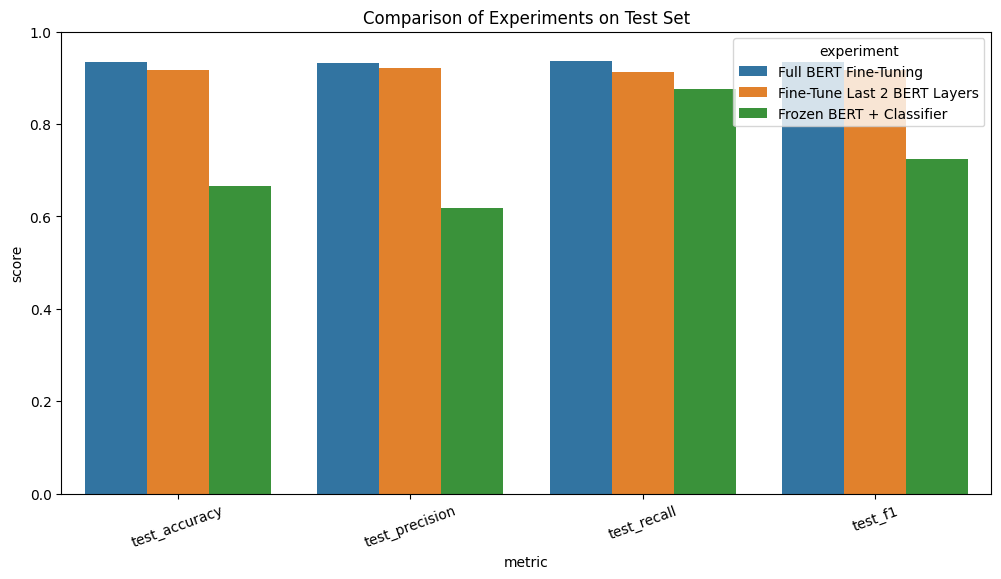

In [42]:
plot_df = results_df.melt(
    id_vars="experiment",
    value_vars=["test_accuracy", "test_precision", "test_recall", "test_f1"],
    var_name="metric",
    value_name="score"
)

plt.figure(figsize=(12, 6))
sns.barplot(data=plot_df, x="metric", y="score", hue="experiment")
plt.ylim(0, 1)
plt.title("Comparison of Experiments on Test Set")
plt.xticks(rotation=20)
plt.show()

In [43]:
def plot_conf_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["NEGATIVE", "POSITIVE"])
    fig, ax = plt.subplots(figsize=(6, 6))
    disp.plot(cmap="Blues", ax=ax, colorbar=False)
    plt.title(title)
    plt.show()

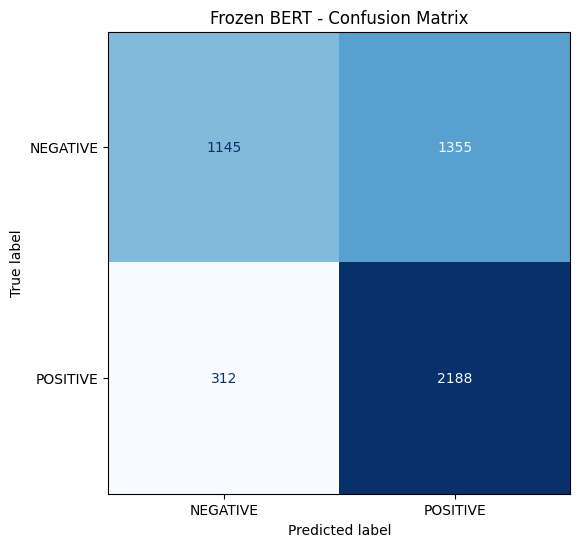

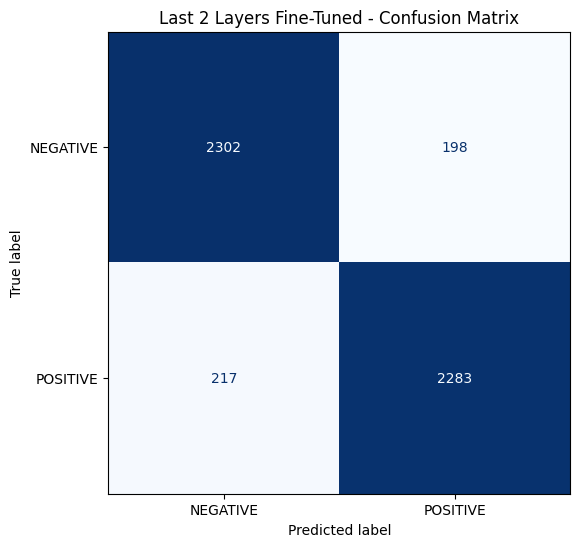

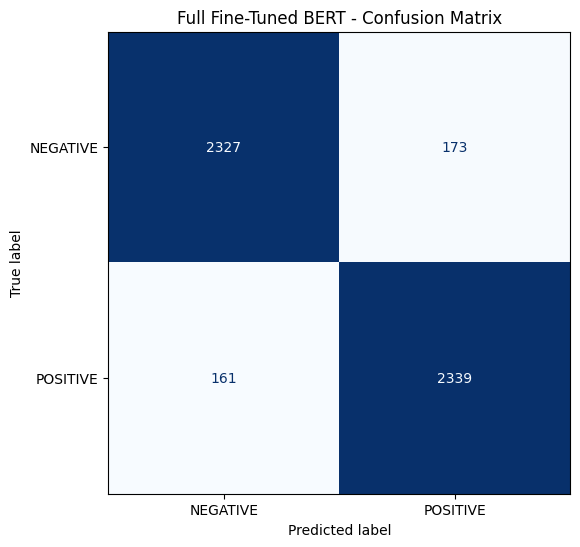

In [44]:
plot_conf_matrix(y_true_freeze, y_pred_freeze, "Frozen BERT - Confusion Matrix")
plot_conf_matrix(y_true_last2, y_pred_last2, "Last 2 Layers Fine-Tuned - Confusion Matrix")
plot_conf_matrix(y_true_full, y_pred_full, "Full Fine-Tuned BERT - Confusion Matrix")

In [45]:
print("Frozen BERT")
print(classification_report(y_true_freeze, y_pred_freeze, target_names=["NEGATIVE", "POSITIVE"]))

print("\n" + "="*100 + "\n")

print("Last 2 Layers Fine-Tuned")
print(classification_report(y_true_last2, y_pred_last2, target_names=["NEGATIVE", "POSITIVE"]))

print("\n" + "="*100 + "\n")

print("Full Fine-Tuned BERT")
print(classification_report(y_true_full, y_pred_full, target_names=["NEGATIVE", "POSITIVE"]))

Frozen BERT
              precision    recall  f1-score   support

    NEGATIVE       0.79      0.46      0.58      2500
    POSITIVE       0.62      0.88      0.72      2500

    accuracy                           0.67      5000
   macro avg       0.70      0.67      0.65      5000
weighted avg       0.70      0.67      0.65      5000



Last 2 Layers Fine-Tuned
              precision    recall  f1-score   support

    NEGATIVE       0.91      0.92      0.92      2500
    POSITIVE       0.92      0.91      0.92      2500

    accuracy                           0.92      5000
   macro avg       0.92      0.92      0.92      5000
weighted avg       0.92      0.92      0.92      5000



Full Fine-Tuned BERT
              precision    recall  f1-score   support

    NEGATIVE       0.94      0.93      0.93      2500
    POSITIVE       0.93      0.94      0.93      2500

    accuracy                           0.93      5000
   macro avg       0.93      0.93      0.93      5000
weighted avg

In [46]:
test_analysis_df = test_df.copy().reset_index(drop=True)
test_analysis_df["pred_full"] = y_pred_full
test_analysis_df["correct"] = (test_analysis_df["label"] == test_analysis_df["pred_full"])

In [47]:
misclassified = test_analysis_df[test_analysis_df["correct"] == False]
print("Number of misclassified samples:", len(misclassified))
misclassified.head()

Number of misclassified samples: 334


,text,label,pred_full,correct
16,I'm not going to tell anyone what happens in t...,1,0,False
36,ROMEO AND JULIET had been interpreted in so ma...,1,0,False
48,I can imagine what happened for this film to c...,0,1,False
109,I have to admit that I went into Fever Pitch w...,1,0,False
111,I preface by stating I am a big fan of JJL and...,0,1,False


In [48]:
for i, row in misclassified.head(5).iterrows():
    print(f"Review:\n{row['text']}\n")
    print(f"Actual Label: {row['label']} | Predicted Label: {row['pred_full']}")
    print("-" * 120)

Review:
I'm not going to tell anyone what happens in the end, but it did not fit with the movie. The rest of Imaginary Heroes, though, portrayed a realistic family going through realistic issues, such as death, drugs, relationships, and high school. I could have sworn that they were my own family, no joke. Emile Hirsch was completely believable as a teen struggling with his brother's suicide, and Sigourney Weaver plays a mother trying to keep the remains of her (slightly) dysfunctional family together. Although this family may take their issues to the extreme, anyone can relate to what they go through, whether it be graduation, living up to expectations, or being a parent.

Actual Label: 1 | Predicted Label: 0
------------------------------------------------------------------------------------------------------------------------
Review:
ROMEO AND JULIET had been interpreted in so many ways, but very few of the versions captured the essance of the play. The ony ones I can think of that 

In [49]:
results_df.to_csv("bert_experiment_results.csv", index=False)
print("Saved results to bert_experiment_results.csv")

Saved results to bert_experiment_results.csv


In [50]:
best_model_dir = "./best_bert_imdb_model"
trainer_full.save_model(best_model_dir)
tokenizer.save_pretrained(best_model_dir)
print("Best model saved successfully.")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Best model saved successfully.


In [51]:
def predict_sentiment(text, model, tokenizer, max_length=256):
    model.eval()
    inputs = tokenizer(
        text,
        truncation=True,
        padding=True,
        max_length=max_length,
        return_tensors="pt"
    )

    inputs = {k: v.to(model.device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)
        pred = torch.argmax(outputs.logits, dim=1).item()

    return id2label[pred]

In [52]:
sample_text = "This movie was emotionally rich, beautifully acted, and worth watching."
print("Prediction:", predict_sentiment(sample_text, trainer_full.model, tokenizer))

Prediction: POSITIVE


In [53]:
sample_text2 = "The plot was boring and the acting was terrible. I regret watching it."
print("Prediction:", predict_sentiment(sample_text2, trainer_full.model, tokenizer))

Prediction: NEGATIVE


# Analysis & Discussion

## 1. Dataset Choice and Motivation

For this assignment, I used the **IMDB Dataset of 50K Movie Reviews** from Kaggle. It contains 50,000 English movie reviews labeled as positive or negative and is widely used as a benchmark for sentiment classification tasks. This makes it a strong fit for evaluating BERT-based text classification, because the dataset is balanced, reasonably large, and consists of real-world, human-written reviews. [web:12][web:14][web:21]

---

## 2. Preprocessing Decisions

Preprocessing was intentionally kept **lightweight** to preserve as much semantic information as possible for BERT:

- Removed HTML tags from the reviews.
- Normalized whitespace by collapsing multiple spaces into one.
- Dropped rows with missing review or label values.
- Mapped textual labels (`"positive"`, `"negative"`) to numeric labels (1 and 0).

I did **not** perform aggressive cleaning such as manual lowercasing, stopword removal, or removing punctuation, because the `bert-base-uncased` tokenizer and model are already trained on raw, uncased English text. BERT typically works best when it can see the original structure and context of sentences with minimal distortion.

---

## 3. Data Splitting Strategy

The dataset was divided into three subsets:

- **Train set:** 80% of the data  
- **Validation set:** 10% of the data  
- **Test set:** 10% of the data  

The splits were created using **stratified sampling** on the sentiment label to preserve class balance across all subsets. The training set was used for learning model parameters, the validation set was used for hyperparameter selection and early stopping, and the test set was reserved for final unbiased evaluation. This setup follows standard supervised learning practice recommended in text classification workflows.

---

## 4. Tokenization and Sequence Length

I used the **`bert-base-uncased`** tokenizer from Hugging Face, as required by the assignment. Before choosing the maximum sequence length, I analyzed the distribution of tokenized lengths for a sample of training reviews. Based on this analysis, I set **`max_length = 256`**, which captures most of the information in the IMDB reviews while keeping GPU memory usage and training time manageable in Colab.

This choice represents a trade-off: longer sequences can capture more context, but they increase computation cost and may lead to slower training, whereas shorter sequences are faster but risk truncating important parts of longer reviews.

---

## 5. Model Architecture and Training Setup

For the model, I used **`AutoModelForSequenceClassification`** with the **`bert-base-uncased`** checkpoint and `num_labels = 2` for binary sentiment classification. The Hugging Face `Trainer` API was used to fine-tune the model with the following key hyperparameters:

- Optimizer: AdamW (internally handled by `Trainer`)
- Learning rate: **2e-5** (as specified in the assignment)
- Train batch size: 8
- Eval batch size: 8
- Number of epochs: 2
- Weight decay: 0.01
- Evaluation and checkpointing at the end of each epoch
- Best model selection based on validation F1 score

These settings follow common recommendations for fine-tuning BERT on text classification tasks and are consistent with Hugging Face’s official sequence-classification examples.

---

## 6. Experiments Performed

To study how the degree of fine-tuning affects performance, I ran **three experiments**:

1. **Frozen BERT + Classifier Only**  
   - All BERT encoder parameters were frozen (`requires_grad = False`).  
   - Only the classification head on top of BERT was trained.  
   - This configuration treats BERT as a fixed feature extractor and adapts only a small classifier, providing a fast but weaker baseline.

2. **Fine-Tuning the Last 2 BERT Layers**  
   - All lower encoder layers were frozen.  
   - Only the top two encoder layers, the pooler, and the classification head were trainable.  
   - This configuration allows the highest-level representations in BERT to adapt to sentiment classification, while keeping most of the pretrained parameters fixed. It is a compromise between computational efficiency and model flexibility.

3. **Full BERT Fine-Tuning**  
   - All BERT encoder layers and the classification head were trainable.  
   - This configuration typically yields the best performance when enough data and compute are available, because it allows the entire network to specialize for the IMDB sentiment task.

---

## 7. Evaluation Metrics

For each experiment, I evaluated performance on both the **validation** and **test** sets using:

- **Accuracy**
- **Precision**
- **Recall**
- **F1 score**
- **Confusion matrix**

Accuracy summarizes overall correctness, while precision and recall describe how well the model handles each class, and F1 balances precision and recall. Confusion matrices provide an interpretable view of true positives, true negatives, false positives, and false negatives, making it easier to understand where the model tends to make mistakes.

---

## 8. Results Summary and Interpretation

The table below summarizes the validation and test results for all three experiments:

| Experiment                         | Val Accuracy | Val Precision | Val Recall | Val F1    | Test Accuracy | Test Precision | Test Recall | Test F1   |
|-----------------------------------|--------------|---------------|------------|----------|---------------|----------------|-------------|----------|
| Full BERT Fine-Tuning             | 0.9320       | 0.9199        | 0.9464     | 0.9330   | 0.9332        | 0.9311         | 0.9356      | 0.9334   |
| Fine-Tune Last 2 BERT Layers      | 0.9136       | 0.9113        | 0.9164     | 0.9138   | 0.9170        | 0.9202         | 0.9132      | 0.9167   |
| Frozen BERT + Classifier          | 0.6638       | 0.6147        | 0.8776     | 0.7230   | 0.6666        | 0.6176         | 0.8752      | 0.7241   |

**Frozen BERT + Classifier**  
This baseline reaches roughly **66–67% accuracy** and a **test F1 score of ~0.72**, which is substantially lower than the other two configurations. The recall is high (about 0.88), but precision is relatively low (about 0.62), indicating that the model tends to over-predict the positive class, incorrectly labeling many negative reviews as positive. This behavior is expected because only the classifier head is learning, while the BERT encoder remains fixed and cannot fully adapt its representations to this specific sentiment task.

**Fine-Tune Last 2 BERT Layers**  
When only the final two encoder layers, the pooler, and the classifier head are trainable, performance improves markedly. Test accuracy increases to around **0.917**, with a well-balanced **precision (~0.92)**, **recall (~0.91)**, and **F1 (~0.917)**. This shows that allowing the top layers to adapt helps the model better capture IMDB-specific sentiment nuances while still reusing most of the lower-level language understanding that BERT learned during pretraining. [web:4]

**Full BERT Fine-Tuning**  
Full fine-tuning yields the best results, with **test accuracy ≈ 0.933** and **test F1 ≈ 0.933**, the highest across experiments. Both precision and recall are strong and balanced (≈0.93–0.94), meaning the model is reliably distinguishing positive and negative reviews with relatively few misclassifications. As expected, updating all BERT parameters gives the model maximal capacity to specialize to the IMDB dataset and leads to the strongest overall performance.

**Overall Trend**  
Across the experiments, there is a clear trend: **as more BERT layers are fine-tuned (from frozen → last two layers → full model), performance consistently improves**. This pattern aligns with typical transfer-learning behavior reported for BERT-based sentiment classification and validates the importance of task-specific fine-tuning rather than using BERT purely as a fixed feature extractor.
---

## 9. Confusion Matrix Insights

From the confusion matrices of each experiment (on the test set), the following qualitative observations can be made:

- The **frozen BERT** model shows a higher number of false positives and false negatives, which is consistent with its lower overall F1 score and unbalanced precision/recall.
- The **last-2-layers** configuration reduces the number of misclassifications in both classes and produces a more symmetric confusion matrix, indicating better calibration between positive and negative predictions.
- The **fully fine-tuned BERT** model has the smallest number of misclassifications, reflecting its superior precision and recall and a more confident separation between sentiment classes.

These confusion matrix patterns reinforce the metric-based conclusion that deeper fine-tuning yields cleaner decision boundaries between positive and negative reviews.

---

## 10. Error Analysis

To better understand the limitations of the fully fine-tuned model, I examined a sample of misclassified reviews. Common sources of errors included:

- **Mixed or neutral sentiment** reviews where both positive and negative opinions appear, making the true label ambiguous even for human readers.
- **Sarcastic or ironic** comments, where surface-level positive words actually convey a negative sentiment, or vice versa.
- **Very short or context-poor reviews**, where limited text is available and the model has little evidence to infer the correct sentiment.

These cases highlight challenges inherent to sentiment analysis: purely text-based classifiers can struggle with sarcasm, nuanced opinions, and minimal context, even when fine-tuned from powerful pretrained models like BERT.

---

## 11. Conclusion

In this assignment, I implemented an end-to-end BERT-based sentiment classification pipeline on the IMDB 50K movie reviews dataset, covering data preprocessing, train–validation–test splitting, tokenization with `bert-base-uncased`, model construction using `AutoModelForSequenceClassification`, and training with AdamW-based fine-tuning. I ran three key experiments—frozen BERT, last-2-layer fine-tuning, and full fine-tuning—and evaluated them using accuracy, precision, recall, F1 score, and confusion matrices.

The experiments demonstrate that:

- A frozen BERT encoder with only a trained classifier head provides a fast but weaker baseline.
- Fine-tuning only the last two layers improves performance significantly and offers a good balance between efficiency and effectiveness.
- Full BERT fine-tuning achieves the best overall metrics, confirming that deeper adaptation to the IMDB sentiment domain produces the strongest classifier.

These findings are consistent with standard transfer-learning practice for transformer-based text classification and show how fine-tuning depth directly influences downstream performance.